# Training Intent Recognition Chatbot Robot Jadul
Notebook ini siap dipakai di **Google Colab** untuk melatih model **TF-IDF + Logistic Regression** pada dataset intent chatbot e-commerce Robot Jadul.

## Isi notebook
1. Import library
2. Upload / baca dataset
3. Validasi dataset
4. Analisis distribusi kelas
5. Train-test split
6. Training model TF-IDF + Logistic Regression
7. Evaluasi metrik utama
8. Classification report
9. Confusion matrix
10. Diagram distribusi dan per-class metrics
11. Cross-validation
12. Error analysis
13. **Optional ambiguous/noise addon**
14. **Hard manual test** (manual input + optional CSV)
15. Simpan model dan report


In [ ]:
# =========================================================
# 1) INSTALL & IMPORT LIBRARY
# =========================================================
# Jalankan cell ini sekali di Google Colab

!pip -q install scikit-learn pandas matplotlib joblib seaborn

import io
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_colwidth", 200)


## 2) Upload dataset
Upload **dataset utama** terlebih dahulu.  
Kalau mau evaluasi yang lebih valid, kamu juga bisa sekalian upload:

- `dataset_intent_final_ready_training.csv` → **wajib**
- `dataset_intent_noise_ambiguous_addon.csv` → **opsional**, untuk menambah noise / kalimat ambigu ke data training
- `dataset_intent_hard_manual_test.csv` → **opsional**, untuk uji manual tambahan

Notebook ini akan mendeteksi file berdasarkan nama filenya.


In [ ]:
# =========================================================
# 2) UPLOAD / BACA DATASET
# =========================================================

uploaded = files.upload()
uploaded_names = list(uploaded.keys())

if not uploaded_names:
    raise ValueError("Tidak ada file yang di-upload.")

print("File yang ter-upload:")
for name in uploaded_names:
    print("-", name)

def find_uploaded_file(keyword_list):
    for name in uploaded_names:
        lower = name.lower()
        if all(k in lower for k in keyword_list):
            return name
    return None

# Wajib: dataset utama
DATASET_PATH = find_uploaded_file(["final", "ready", "training"])
if DATASET_PATH is None:
    # fallback: ambil file CSV pertama kalau nama file berbeda
    csv_files = [n for n in uploaded_names if n.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("Dataset utama CSV tidak ditemukan.")
    DATASET_PATH = csv_files[0]

print("\nDataset utama terpilih:", DATASET_PATH)

# Custom parsing function to handle malformed CSVs where text column might contain commas
def parse_malformed_csv(filepath):
    data = []
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        csv_reader = csv.reader(f, quotechar='"', doublequote=True)
        header = next(csv_reader) # Read header
        if header != ['text', 'label']:
            print(f"Warning: CSV header is {header}, expected ['text', 'label']. Attempting to parse anyway.")

        for i, row in enumerate(csv_reader):
            if not row:
                continue
            # Assume the last element is the label, and join everything before it as text
            label = row[-1]
            text = ','.join(row[:-1])
            data.append([text, label])
    return pd.DataFrame(data, columns=['text', 'label'])

try:
    # First try default pandas read_csv for clean files
    df = pd.read_csv(DATASET_PATH, encoding='utf-8-sig', quotechar='"', doublequote=True)
    print("Successfully read CSV with default pandas engine.")
except pd.errors.ParserError as e:
    print(f"Error reading CSV with default pandas engine: {e}")
    print("Attempting custom parsing to handle malformed lines...")
    df = parse_malformed_csv(DATASET_PATH)
    print("Successfully read with custom parser. Please verify the dataframe content.")


# Opsional: addon noise/ambigu
AMBIGUOUS_PATH = find_uploaded_file(["noise"]) or find_uploaded_file(["ambiguous"]) or find_uploaded_file(["addon"])
if AMBIGUOUS_PATH:
    print("Dataset addon terdeteksi:", AMBIGUOUS_PATH)
else:
    print("Dataset addon tidak ditemukan. Lanjut tanpa addon.")

# Opsional: hard manual test CSV
HARD_TEST_PATH = find_uploaded_file(["hard", "manual", "test"])
if HARD_TEST_PATH:
    print("Hard manual test CSV terdeteksi:", HARD_TEST_PATH)
else:
    print("Hard manual test CSV tidak ditemukan. Nanti bisa pakai input manual list.")

df.head()

Saving dataset_intent_final_ready_training.csv to dataset_intent_final_ready_training (11).csv
Saving dataset_intent_hard_manual_test.csv to dataset_intent_hard_manual_test (11).csv
Saving dataset_intent_noise_ambiguous_addon.csv to dataset_intent_noise_ambiguous_addon (11).csv
File yang ter-upload:
- dataset_intent_final_ready_training (11).csv
- dataset_intent_hard_manual_test (11).csv
- dataset_intent_noise_ambiguous_addon (11).csv

Dataset utama terpilih: dataset_intent_final_ready_training (11).csv
Error reading CSV with default pandas engine: Error tokenizing data. C error: Expected 2 fields in line 6, saw 3

Attempting custom parsing to handle malformed lines...
Successfully read with custom parser. Please verify the dataframe content.
Dataset addon terdeteksi: dataset_intent_noise_ambiguous_addon (11).csv
Hard manual test CSV terdeteksi: dataset_intent_hard_manual_test (11).csv


,text,label
0,bisa kirim voltes v ke jogja ga,shipping_transaction
1,ukuran getter robo ini kira kira brp,product_detail
2,kapan mazinger z restock kalau habis,stock_availability
3,butuh info kisaran harga robot jadul karena mau buat hadiah,price_promo
4,"aku mau nanya, kalau grendizer ini lagi sale ga sih soalnya takut stoknya habis",price_promo


### Inspecting malformed lines in the CSV

The previous error indicated that line 6 had an unexpected number of fields (3 instead of 2). This script will help you manually inspect the CSV file to find lines that don't conform to the expected column count. Please note that it assumes a comma-separated file and uses a basic split, which might not handle quoted commas perfectly. However, it should help identify the primary issue.

In [ ]:
import csv

# Assuming 2 expected columns based on the error message
expected_columns = 2

print(f"Inspecting file: {DATASET_PATH}")
print(f"Expected number of columns: {expected_columns}\n")

malformed_lines = []
with open(DATASET_PATH, 'r', encoding='utf-8-sig') as f:
    csv_reader = csv.reader(f)
    for i, row in enumerate(csv_reader):
        # For each row, count the number of fields. Skip header row if it exists.
        # If the file uses '"' as quotechar and doublequote=True, csv.reader handles it.
        if len(row) != expected_columns:
            malformed_lines.append((i + 1, len(row), ','.join(row)))

if malformed_lines:
    print("Found lines with an incorrect number of columns:")
    for line_num, actual_cols, line_content in malformed_lines:
        print(f"Line {line_num}: Expected {expected_columns} fields, saw {actual_cols}. Content: {line_content}")
else:
    print("All lines appear to have the expected number of columns.")

Inspecting file: dataset_intent_final_ready_training (11).csv
Expected number of columns: 2

Found lines with an incorrect number of columns:
Line 6: Expected 2 fields, saw 3. Content: aku mau nanya, kalau grendizer ini lagi sale ga sih soalnya takut stoknya habis,price_promo
Line 18: Expected 2 fields, saw 3. Content: mau nanya, cek dong gaiking stoknya aman ga,stock_availability
Line 22: Expected 2 fields, saw 3. Content: boleh tanya, aku mau tau aturan refund sebelum beli,return_product
Line 26: Expected 2 fields, saw 3. Content: boleh tanya, pengiriman goldrake aman ga kalau ke medan,shipping_transaction
Line 33: Expected 2 fields, saw 3. Content: mau nanya, ini toko ada offline juga atau cuma online,shipping_origin
Line 36: Expected 2 fields, saw 4. Content: mau nanya, buat pajangan meja, yg cocok dari toko ini apa,recommendation
Line 38: Expected 2 fields, saw 3. Content: boleh tanya, robot jadul ini ada minus di bagian tertentu ga biar lebih yakin sebelum order,product_detail
Li

In [ ]:
# =========================================================
# 3) VALIDASI DATASET
# =========================================================
required_cols = {"text", "label"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Dataset wajib punya kolom: {required_cols}, tapi sekarang: {set(df.columns)}")

print("Jumlah data:", len(df))
print("Kolom:", list(df.columns))
print("Jumlah label unik:", df["label"].nunique())
print("\nDaftar label:")
print(sorted(df["label"].unique()))

print("\nCek missing value:")
print(df[["text", "label"]].isna().sum())

print("\nCek exact duplicate rows:")
print(df.duplicated(subset=["text", "label"]).sum())

# Bersihkan data ringan
df["text"] = df["text"].astype(str).str.strip()
df["label"] = df["label"].astype(str).str.strip()
df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print("\nJumlah data setelah cleaning:", len(df))
df.sample(min(10, len(df)), random_state=42)


Jumlah data: 1764
Kolom: ['text', 'label']
Jumlah label unik: 10

Daftar label:
['general', 'price_promo', 'product_detail', 'product_discovery', 'recommendation', 'return_product', 'shipping_origin', 'shipping_transaction', 'stock_availability', 'transaction_status']

Cek missing value:
text     0
label    0
dtype: int64

Cek exact duplicate rows:
123

Jumlah data setelah cleaning: 1641


,text,label
677,"aku mau nanya, harga super robot sekarang berapa",price_promo
1340,kondisi fisik goldrake ini masih mulus ga,product_detail
984,"mau nanya, kalau fokus nostalgia, item yang paling menarik apa",recommendation
607,habis checkout nanti pembayaran lewat apa aja,shipping_transaction
1394,apakah toko ini fokus di koleksi robot lama soalnya lagi bandingin dulu,general
1033,order 3007 sudah dikirim atau belum,transaction_status
1586,"izin tanya, yang keliatan premium biasanya yang mana",recommendation
1311,asal toko kalian dari mana,shipping_origin
1239,retur untuk barang koleksi seperti grendizer berlaku ga,return_product
271,"boleh tanya, mau cari figure robot yang bukan preorder ada biar lebih yakin sebelum order",product_discovery


## 3b) Optional addon dataset (noise / ambiguous)
Kalau file addon di-upload, cell ini akan:
- validasi kolom `text` dan `label`
- menggabungkan addon ke dataset utama
- menghapus duplicate exact pair `text` + `label`

Tujuannya supaya evaluasi model jadi lebih menantang dan lebih valid.


In [ ]:
# =========================================================
# 3b) OPTIONAL ADDON DATASET (NOISE / AMBIGUOUS)
# =========================================================
required_cols = {"text", "label"}

if AMBIGUOUS_PATH:
    addon_df = pd.read_csv(AMBIGUOUS_PATH)

    if not required_cols.issubset(addon_df.columns):
        raise ValueError(f"Addon dataset wajib punya kolom: {required_cols}, tapi sekarang: {set(addon_df.columns)}")

    print("Jumlah data utama sebelum addon:", len(df))
    print("Jumlah data addon:", len(addon_df))

    df = pd.concat([df, addon_df], ignore_index=True)
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip()

    before_dedup = len(df)
    df = df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    after_dedup = len(df)

    print("Jumlah data setelah digabung:", before_dedup)
    print("Jumlah data setelah drop duplicate exact pair:", after_dedup)
else:
    print("Tidak ada addon dataset. Dataset utama dipakai apa adanya.")

display(df.sample(min(5, len(df)), random_state=42))


Jumlah data utama sebelum addon: 1641
Jumlah data addon: 100
Jumlah data setelah digabung: 1741
Jumlah data setelah drop duplicate exact pair: 1740


,text,label
482,"mau nanya, harga nett voltron berapa",price_promo
1507,boleh tau kondisi fisik grendizer lebih detail,product_detail
950,kalau barang ga sesuai deskripsi bisa dikembalikan ga karena mau buat hadiah,return_product
1005,status paket dari order saya bagaimana,transaction_status
705,"lagi cari gundam, ada ga di sini",product_discovery


,label,count
0,stock_availability,200
1,recommendation,190
2,product_detail,180
3,shipping_transaction,180
4,price_promo,180
5,return_product,180
6,product_discovery,180
7,shipping_origin,152
8,general,150
9,transaction_status,148


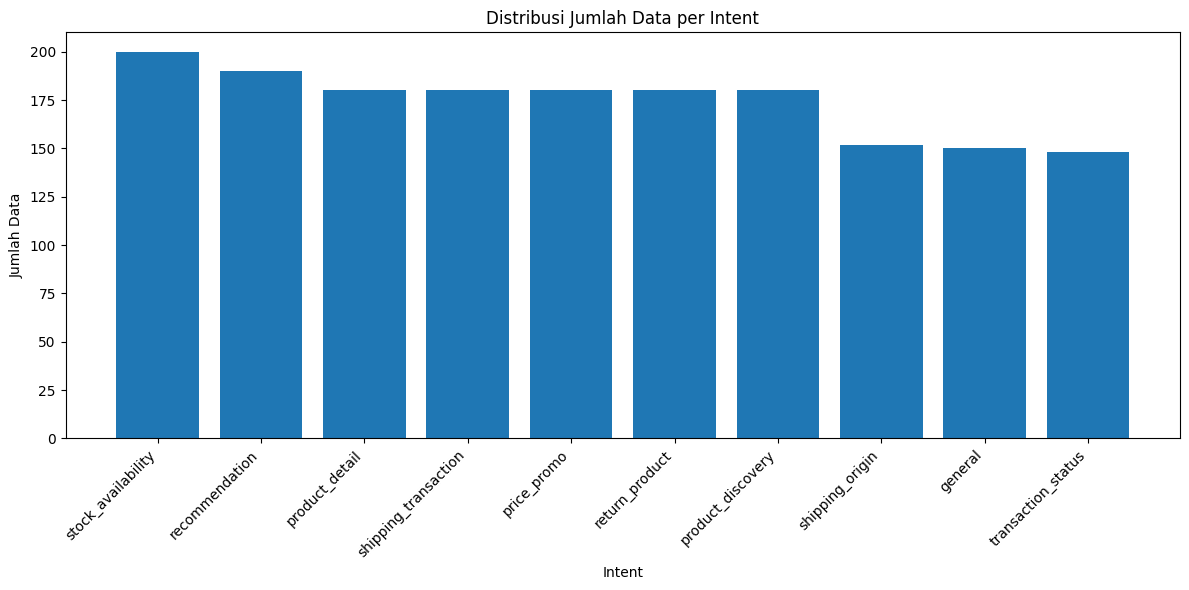

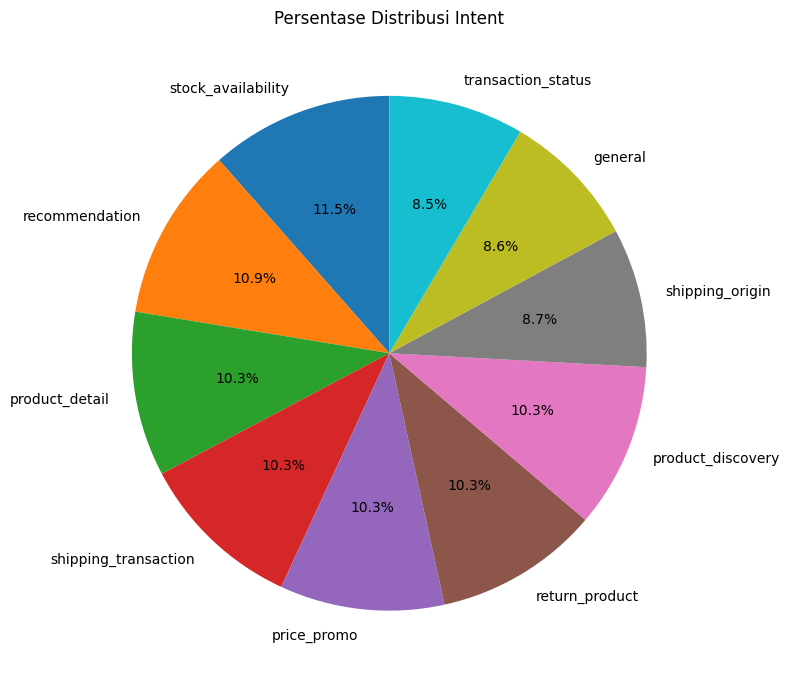

In [ ]:
# =========================================================
# 4) ANALISIS DISTRIBUSI KELAS
# =========================================================
class_dist = df["label"].value_counts().sort_values(ascending=False)
dist_df = class_dist.reset_index()
dist_df.columns = ["label", "count"]

display(dist_df)

plt.figure(figsize=(12, 6))
plt.bar(dist_df["label"], dist_df["count"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribusi Jumlah Data per Intent")
plt.xlabel("Intent")
plt.ylabel("Jumlah Data")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.pie(dist_df["count"], labels=dist_df["label"], autopct="%1.1f%%", startangle=90)
plt.title("Persentase Distribusi Intent")
plt.tight_layout()
plt.show()


## 5) Pisahkan fitur dan label
Pada tahap ini dataset dibagi menjadi:
- `X` = teks pertanyaan user
- `y` = label intent


In [ ]:
# =========================================================
# 5) FITUR & LABEL
# =========================================================
X = df["text"]
y = df["label"]

# Encode label untuk penyimpanan model (opsional)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Mapping label -> index:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{i}: {label}")


Mapping label -> index:
0: general
1: price_promo
2: product_detail
3: product_discovery
4: recommendation
5: return_product
6: shipping_origin
7: shipping_transaction
8: stock_availability
9: transaction_status


In [ ]:
# =========================================================
# 6) TRAIN-TEST SPLIT
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

print("\nDistribusi train:")
print(y_train.value_counts())

print("\nDistribusi test:")
print(y_test.value_counts())


Jumlah data train: 1392
Jumlah data test : 348

Distribusi train:
label
stock_availability      160
recommendation          152
product_discovery       144
return_product          144
product_detail          144
price_promo             144
shipping_transaction    144
shipping_origin         122
general                 120
transaction_status      118
Name: count, dtype: int64

Distribusi test:
label
stock_availability      40
recommendation          38
return_product          36
product_discovery       36
product_detail          36
price_promo             36
shipping_transaction    36
general                 30
transaction_status      30
shipping_origin         30
Name: count, dtype: int64


## 7) Bangun pipeline model
Pipeline yang dipakai:
- **TF-IDF** untuk ekstraksi fitur teks
- **Logistic Regression** untuk klasifikasi intent


In [ ]:
# =========================================================
# 7) PIPELINE TF-IDF + LOGISTIC REGRESSION
# =========================================================
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        class_weight=None,
        random_state=42
    ))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Training selesai.")


Training selesai.


In [ ]:
# =========================================================
# 8) EVALUASI UTAMA
# =========================================================
accuracy  = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall_macro    = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1_macro        = f1_score(y_test, y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall_weighted    = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1_weighted        = f1_score(y_test, y_pred, average="weighted", zero_division=0)

metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-Score (Macro)",
        "Precision (Weighted)",
        "Recall (Weighted)",
        "F1-Score (Weighted)"
    ],
    "Value": [
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro,
        precision_weighted,
        recall_weighted,
        f1_weighted
    ]
})

display(metrics_summary.style.format({"Value": "{:.4f}"}))


,Metric,Value
0,Accuracy,0.9741
1,Precision (Macro),0.9768
2,Recall (Macro),0.9744
3,F1-Score (Macro),0.9750
4,Precision (Weighted),0.9750
5,Recall (Weighted),0.9741
6,F1-Score (Weighted),0.9740


In [ ]:
# =========================================================
# 9) CLASSIFICATION REPORT
# =========================================================
labels = sorted(y.unique())

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()

print("=== CLASSIFICATION REPORT (TEST SPLIT) ===")
display(report_df.style.format("{:.4f}"))

per_class = pd.DataFrame(report_dict).T
per_class = per_class.loc[[lbl for lbl in labels if lbl in per_class.index], ["precision", "recall", "f1-score", "support"]]

print("\n=== METRIK PER KELAS (TEST SPLIT) ===")
display(per_class.style.format({"precision":"{:.4f}", "recall":"{:.4f}", "f1-score":"{:.4f}", "support":"{:.0f}"}))


=== CLASSIFICATION REPORT (TEST SPLIT) ===


,precision,recall,f1-score,support
general,1.0000,0.9667,0.9831,30.0000
price_promo,0.9444,0.9444,0.9444,36.0000
product_detail,1.0000,0.8889,0.9412,36.0000
product_discovery,0.9714,0.9444,0.9577,36.0000
recommendation,0.9268,1.0000,0.9620,38.0000
return_product,1.0000,1.0000,1.0000,36.0000
shipping_origin,1.0000,1.0000,1.0000,30.0000
shipping_transaction,0.9730,1.0000,0.9863,36.0000
stock_availability,0.9524,1.0000,0.9756,40.0000
transaction_status,1.0000,1.0000,1.0000,30.0000



=== METRIK PER KELAS (TEST SPLIT) ===


,precision,recall,f1-score,support
general,1.0000,0.9667,0.9831,30
price_promo,0.9444,0.9444,0.9444,36
product_detail,1.0000,0.8889,0.9412,36
product_discovery,0.9714,0.9444,0.9577,36
recommendation,0.9268,1.0000,0.9620,38
return_product,1.0000,1.0000,1.0000,36
shipping_origin,1.0000,1.0000,1.0000,30
shipping_transaction,0.9730,1.0000,0.9863,36
stock_availability,0.9524,1.0000,0.9756,40
transaction_status,1.0000,1.0000,1.0000,30


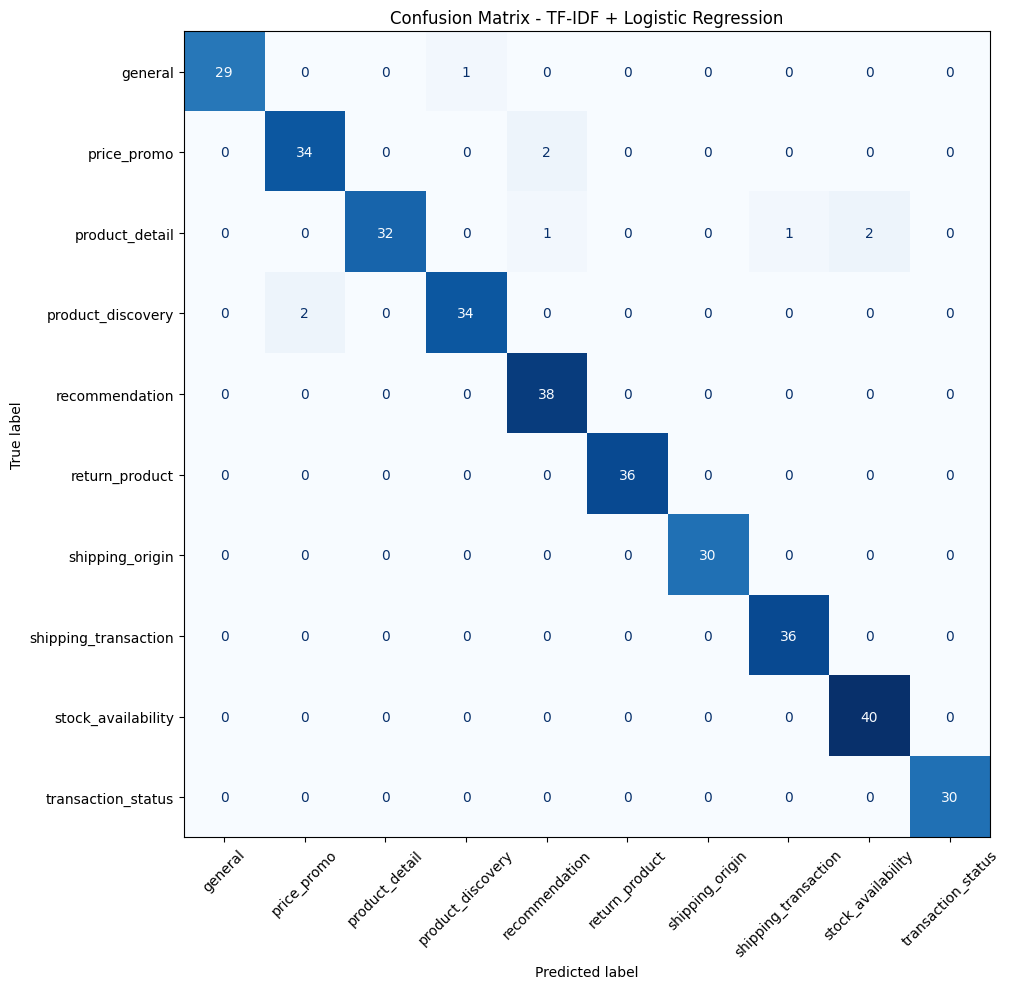

In [ ]:
# =========================================================
# 10) CONFUSION MATRIX
# =========================================================
labels_sorted = labels
cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()


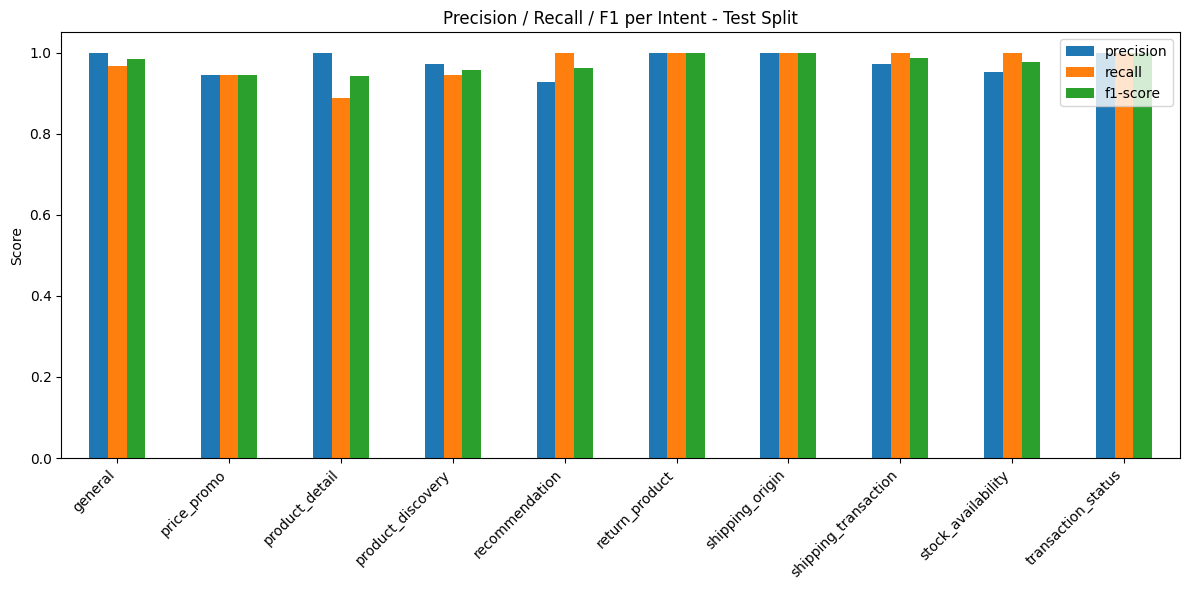

,precision,recall,f1-score,support
shipping_origin,1.0000,1.0000,1.0000,30
return_product,1.0000,1.0000,1.0000,36
transaction_status,1.0000,1.0000,1.0000,30
shipping_transaction,0.9730,1.0000,0.9863,36
general,1.0000,0.9667,0.9831,30
stock_availability,0.9524,1.0000,0.9756,40
recommendation,0.9268,1.0000,0.9620,38
product_discovery,0.9714,0.9444,0.9577,36
price_promo,0.9444,0.9444,0.9444,36
product_detail,1.0000,0.8889,0.9412,36


In [ ]:
# =========================================================
# 11) DIAGRAM PER-CLASS METRICS
# =========================================================
metric_cols = ["precision", "recall", "f1-score"]

ax = per_class[metric_cols].plot(kind="bar", figsize=(12, 6))
plt.title("Precision / Recall / F1 per Intent - Test Split")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Versi terurut berdasarkan F1-score
per_class_sorted = per_class.sort_values("f1-score", ascending=False)
display(per_class_sorted.style.format({"precision":"{:.4f}", "recall":"{:.4f}", "f1-score":"{:.4f}", "support":"{:.0f}"}))


In [ ]:
# =========================================================
# 12) RINGKASAN KESALAHAN PREDIKSI
# =========================================================
error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

errors_only = error_df[error_df["actual"] != error_df["predicted"]].copy()
print("Jumlah salah prediksi:", len(errors_only))
display(errors_only.head(30))


Jumlah salah prediksi: 9


,text,actual,predicted
33,kalau dari detailnya dancouga ini masih layak koleksi ga karena aku masih pertimbangin juga,product_detail,stock_availability
86,"kalau budget tipis enaknya yang mana, maksimal 500rb",price_promo,recommendation
106,"siang kak, saya mau cari info",general,product_discovery
110,ada mainan robot kisaran sejuta ga,product_discovery,price_promo
166,sendinya bisa gerak semua ga,product_detail,shipping_transaction
207,"kalau budget mentok 1,5 jt ada apa",price_promo,recommendation
252,kalau dari detailnya robot jadul ini masih layak koleksi ga,product_detail,stock_availability
271,kalau dari detailnya mazinger z ini masih layak koleksi ga biar ga salah pilih,product_detail,recommendation
316,robot vintage yg ada apa aja,product_discovery,price_promo


In [ ]:
# =========================================================
# 13) CROSS-VALIDATION
# =========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
cv_f1_macro = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")
cv_precision_macro = cross_val_score(model, X, y, cv=cv, scoring="precision_macro")
cv_recall_macro = cross_val_score(model, X, y, cv=cv, scoring="recall_macro")

cv_result = pd.DataFrame({
    "Fold": [f"Fold-{i+1}" for i in range(5)],
    "Accuracy": cv_accuracy,
    "Precision Macro": cv_precision_macro,
    "Recall Macro": cv_recall_macro,
    "F1 Macro": cv_f1_macro
})

# Fix: Apply format only to numeric columns
display(cv_result.style.format({
    "Accuracy": "{:.4f}",
    "Precision Macro": "{:.4f}",
    "Recall Macro": "{:.4f}",
    "F1 Macro": "{:.4f}"
}))

print("Rata-rata Accuracy      :", round(cv_accuracy.mean(), 4))
print("Rata-rata Precision Mac :", round(cv_precision_macro.mean(), 4))
print("Rata-rata Recall Mac    :", round(cv_recall_macro.mean(), 4))
print("Rata-rata F1 Macro      :", round(cv_f1_macro.mean(), 4))

,Fold,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,Fold-1,0.9828,0.9834,0.9817,0.9822
1,Fold-2,0.9569,0.9573,0.9542,0.9551
2,Fold-3,0.9828,0.9838,0.9832,0.9830
3,Fold-4,0.9684,0.9704,0.9662,0.9671
4,Fold-5,0.9885,0.9895,0.9878,0.9884


Rata-rata Accuracy      : 0.9759
Rata-rata Precision Mac : 0.9769
Rata-rata Recall Mac    : 0.9746
Rata-rata F1 Macro      : 0.9752


,Metric,Mean Score
0,Accuracy,0.9759
1,Precision Macro,0.9769
2,Recall Macro,0.9746
3,F1 Macro,0.9752


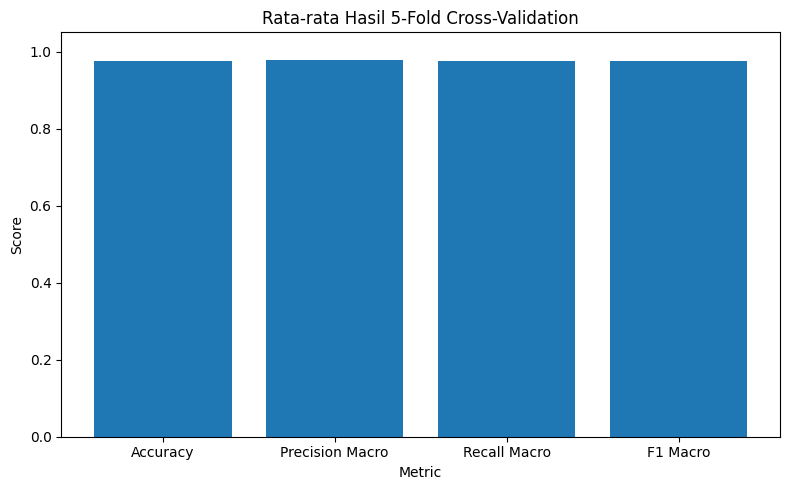

In [ ]:
# =========================================================
# 14) DIAGRAM CROSS-VALIDATION
# =========================================================
cv_means = pd.DataFrame({
    "Metric": ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"],
    "Mean Score": [
        cv_accuracy.mean(),
        cv_precision_macro.mean(),
        cv_recall_macro.mean(),
        cv_f1_macro.mean()
    ]
})

display(cv_means.style.format({"Mean Score": "{:.4f}"}))

plt.figure(figsize=(8, 5))
plt.bar(cv_means["Metric"], cv_means["Mean Score"])
plt.title("Rata-rata Hasil 5-Fold Cross-Validation")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# 15) FEATURE ANALYSIS (KATA PALING KUAT PER INTENT)
# =========================================================
tfidf = model.named_steps["tfidf"]
clf = model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_

top_features = {}

for i, class_label in enumerate(classes):
    top10 = feature_names[np.argsort(clf.coef_[i])[-10:]][::-1]
    top_features[class_label] = top10.tolist()

top_features_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in top_features.items()]))
display(top_features_df)


,general,price_promo,product_detail,product_discovery,recommendation,return_product,shipping_origin,shipping_transaction,stock_availability,transaction_status
0,toko,harga,ini,ada,yang,retur,mana,ke,masih,status
1,buka,promo,detail,cari,apa,barang,di mana,kirim,ready,saya
2,lewat mana,berapa,ukuran,disini,buat,refund,dari,checkout,sekarang,pesanan
3,jam,harganya,yang ini,nyari,rekomendasi,rusak,lokasi,pakai,masih ada,cek
4,admin,diskon,box,ga,paling,bisa,di,bisa,stoknya,order
5,cepat,sekarang,ini kondisinya,juga,yg,komplain,toko,ga kalau,msh,belum
6,lewat,ini lagi,kondisinya,pilihan,yang paling,return,alamat,bisa kirim,stock,sudah
7,info,kisaran,ini apa,ada ga,ambil,return di,dari mana,cara,msh ada,invoice
8,kalau mau,cashback,kondisi,lagi nyari,it,kalau,tokonya,kirim ke,masih tersedia,statusnya
9,cs,cashback untuk,atau ada,yang,worth it,gimana,kota,pembayaran,tersedia,pesanan saya


## 16) Hard manual test
Bagian ini untuk uji tambahan yang lebih menantang.

Ada 2 mode:
1. **CSV opsional**: kalau kamu upload `dataset_intent_hard_manual_test.csv`, notebook akan membacanya
2. **Manual input**: kamu bisa edit list kalimat di cell berikut sesuai kebutuhan

Format hard test CSV:
- kolom `text`
- kolom `label`


In [ ]:
# =========================================================
# 16) HARD MANUAL TEST - SIAPKAN DATA
# =========================================================
manual_hard_samples = [
    {"text": "robot bagus yang murah apa ya", "label": "recommendation"},
    {"text": "ada robot 1 jutaan ga", "label": "product_discovery"},
    {"text": "yang worth it tapi jangan mahal-mahal", "label": "recommendation"},
    {"text": "stok msh ada ga", "label": "stock_availability"},
    {"text": "kirim dr mana min", "label": "shipping_origin"},
    {"text": "cek status order 6864 dong", "label": "transaction_status"},
    {"text": "bisa bayar qris ga", "label": "shipping_transaction"},
    {"text": "ini ori atau bukan", "label": "product_detail"},
    {"text": "lagi promo apa aja", "label": "price_promo"},
    {"text": "barang rusak bisa refund ga", "label": "return_product"},
]

manual_hard_df = pd.DataFrame(manual_hard_samples)

if HARD_TEST_PATH:
    hard_df = pd.read_csv(HARD_TEST_PATH)

    if not {"text", "label"}.issubset(hard_df.columns):
        raise ValueError("Hard manual test CSV wajib punya kolom text dan label")

    print("Hard test CSV dipakai:", HARD_TEST_PATH)
else:
    hard_df = manual_hard_df.copy()
    print("Hard test CSV tidak ada. Menggunakan manual_hard_samples.")

hard_df["text"] = hard_df["text"].astype(str).str.strip()
hard_df["label"] = hard_df["label"].astype(str).str.strip()
hard_df = hard_df.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)

print("Jumlah hard test samples:", len(hard_df))
display(hard_df.head(10))


Hard test CSV dipakai: dataset_intent_hard_manual_test (11).csv
Jumlah hard test samples: 80


,text,label
0,"halo min, aku baru mampir nih",general
1,"permisi kak, boleh tanya sedikit?",general
2,"hai admin, bantu kasih info ya",general
3,"pagi, saya mau nanya-nanya dulu",general
4,"misi, ada yang bisa dibantu?",general
5,hello kak admin,general
6,"sore min, saya baru pertama kali di sini",general
7,izin tanya dulu ya kak,general
8,"kalau dana cuma sekitar sejuta, opsinya apa aja",price_promo
9,under 2 jt ada barang apa yang oke,price_promo


=== HARD MANUAL TEST METRICS ===


,Metric,Value
0,Accuracy,0.8625
1,Precision (Macro),0.8831
2,Recall (Macro),0.8625
3,F1-Score (Macro),0.8575



=== HARD MANUAL TEST REPORT ===


,precision,recall,f1-score,support
general,0.8571,0.7500,0.8000,8.0000
price_promo,0.7500,0.3750,0.5000,8.0000
product_detail,1.0000,1.0000,1.0000,8.0000
product_discovery,0.8750,0.8750,0.8750,8.0000
recommendation,0.5714,1.0000,0.7273,8.0000
return_product,0.8889,1.0000,0.9412,8.0000
shipping_origin,1.0000,0.8750,0.9333,8.0000
shipping_transaction,1.0000,0.7500,0.8571,8.0000
stock_availability,0.8889,1.0000,0.9412,8.0000
transaction_status,1.0000,1.0000,1.0000,8.0000



=== HARD MANUAL TEST - SALAH PREDIKSI ===


,text,label,predicted
0,"permisi kak, boleh tanya sedikit?",general,stock_availability
1,"misi, ada yang bisa dibantu?",general,product_discovery
2,"kalau dana cuma sekitar sejuta, opsinya apa aja",price_promo,recommendation
3,under 2 jt ada barang apa yang oke,price_promo,recommendation
4,lagi ada sale item apa nih,price_promo,recommendation
5,yang promo tapi masih worth it apa,price_promo,recommendation
6,"maks budget saya 500rb, dapet apa",price_promo,recommendation
7,mainan robot kisaran sejuta ada tidak,product_discovery,price_promo
8,kalau mau pickup langsung ke mana,shipping_origin,general
9,kurir yang tersedia apa aja,shipping_transaction,recommendation


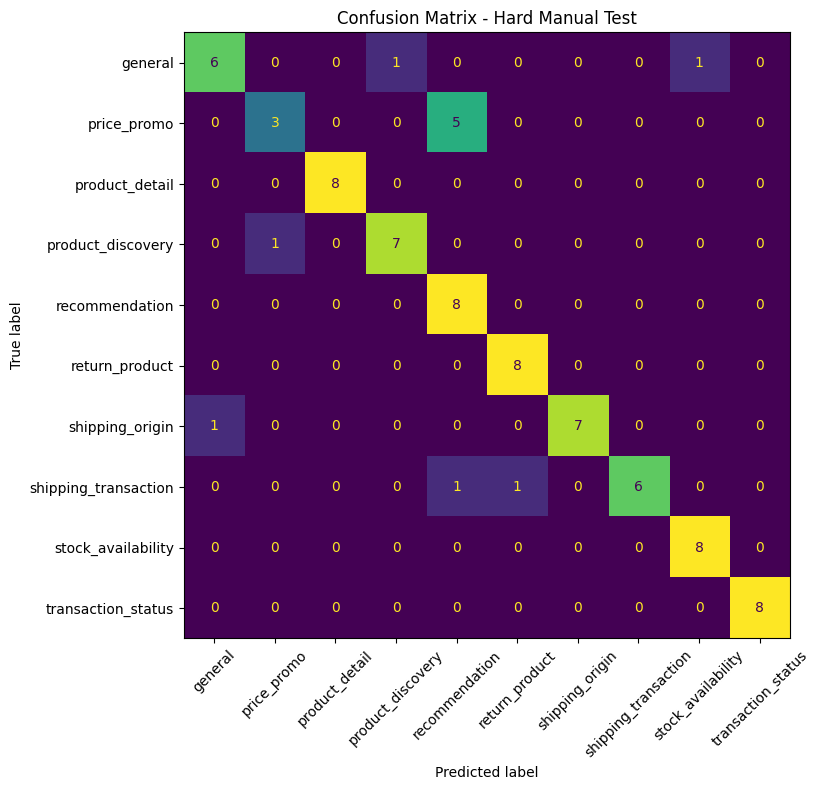

In [ ]:
# =========================================================
# 16b) HARD MANUAL TEST - EVALUASI
# =========================================================
hard_pred = model.predict(hard_df["text"])

hard_accuracy = accuracy_score(hard_df["label"], hard_pred)
hard_precision_macro = precision_score(hard_df["label"], hard_pred, average="macro", zero_division=0)
hard_recall_macro = recall_score(hard_df["label"], hard_pred, average="macro", zero_division=0)
hard_f1_macro = f1_score(hard_df["label"], hard_pred, average="macro", zero_division=0)

hard_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1-Score (Macro)"],
    "Value": [hard_accuracy, hard_precision_macro, hard_recall_macro, hard_f1_macro]
})

print("=== HARD MANUAL TEST METRICS ===")
display(hard_metrics.style.format({"Value":"{:.4f}"}))

hard_report = classification_report(hard_df["label"], hard_pred, output_dict=True, zero_division=0)
hard_report_df = pd.DataFrame(hard_report).T

print("\n=== HARD MANUAL TEST REPORT ===")
display(hard_report_df.style.format("{:.4f}"))

hard_errors = hard_df.copy()
hard_errors["predicted"] = hard_pred
hard_errors = hard_errors[hard_errors["label"] != hard_errors["predicted"]].reset_index(drop=True)

print("\n=== HARD MANUAL TEST - SALAH PREDIKSI ===")
if len(hard_errors) == 0:
    print("Tidak ada salah prediksi pada hard manual test.")
else:
    display(hard_errors)

hard_labels = sorted(set(hard_df["label"]).union(set(hard_pred)))
hard_cm = confusion_matrix(hard_df["label"], hard_pred, labels=hard_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=hard_cm, display_labels=hard_labels)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix - Hard Manual Test")
plt.tight_layout()
plt.show()


In [ ]:
# =========================================================
# 17) SIMPAN MODEL
# =========================================================
os.makedirs("model_output", exist_ok=True)

joblib.dump(model, "model_output/intent_model_tfidf_logreg.joblib")
joblib.dump(label_encoder, "model_output/label_encoder.joblib")
report_df.to_csv("model_output/classification_report.csv", index=True)
metrics_summary.to_csv("model_output/metrics_summary.csv", index=False)
per_class.to_csv("model_output/per_class_metrics.csv", index=True)
errors_only.to_csv("model_output/error_analysis.csv", index=False)
cv_result.to_csv("model_output/cross_validation_result.csv", index=False)
hard_metrics.to_csv("model_output/hard_manual_test_metrics.csv", index=False)
hard_report_df.to_csv("model_output/hard_manual_test_report.csv", index=True)
hard_errors.to_csv("model_output/hard_manual_test_errors.csv", index=False)

print("Semua file model dan report sudah disimpan di folder model_output/")
print(os.listdir("model_output"))


Semua file model dan report sudah disimpan di folder model_output/
['cross_validation_result.csv', 'hard_manual_test_metrics.csv', 'metrics_summary.csv', 'hard_manual_test_report.csv', 'hard_manual_test_errors.csv', 'per_class_metrics.csv', 'classification_report.csv', 'label_encoder.joblib', 'error_analysis.csv', 'intent_model_tfidf_logreg.joblib']


## 17) Download hasil model dan report
Kalau mau simpan ke komputer dari Colab, jalankan cell di bawah.

In [ ]:
# =========================================================
# 18) DOWNLOAD HASIL
# =========================================================
from google.colab import files

for fname in [
    "model_output/intent_model_tfidf_logreg.joblib",
    "model_output/label_encoder.joblib",
    "model_output/classification_report.csv",
    "model_output/metrics_summary.csv",
    "model_output/per_class_metrics.csv",
    "model_output/error_analysis.csv",
    "model_output/cross_validation_result.csv",
    "model_output/hard_manual_test_metrics.csv",
    "model_output/hard_manual_test_report.csv",
    "model_output/hard_manual_test_errors.csv",
]:
    files.download(fname)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Catatan untuk skripsi
Kamu bisa pakai hasil notebook ini untuk:
- **Bab 3**: metode training model TF-IDF + Logistic Regression
- **Bab 4**: hasil evaluasi model menggunakan accuracy, precision, recall, F1-score, confusion matrix, dan cross-validation

## Rumus metrik evaluasi
- **Accuracy** = proporsi prediksi yang benar terhadap seluruh data uji
- **Precision** = proporsi prediksi suatu kelas yang benar
- **Recall** = proporsi data suatu kelas yang berhasil dikenali model
- **F1-score** = rata-rata harmonik precision dan recall

## Interpretasi umum
- Semakin mendekati **1.00**, semakin baik performa model.
- Perhatikan juga confusion matrix untuk melihat intent mana yang paling sering tertukar.
